# EPCRC gamma sweep: pruners vs the certified optimum

Source: `results/sweep.json`, produced by `python experiments/run_all.py`.

Two different semantics are plotted together, so read the legend carefully:

- **protocol** (`forward`, `forward_trim`, `backward`, `backward_kswap2/3`, `pq_kswap`) —
  routing weights are fitted on `Y_fit` and scored on `Y_eval`. This is the deployable
  setting. `E` is non-monotone here, so none of these greedy methods has an optimality
  guarantee.
- **oracle optimum** — routing weights are chosen directly against `Y_eval`. That is
  strictly more permissive, so it is a *lower bound*:
  `|OPT_oracle| <= |OPT_protocol| <= |any pruner|`.
  It is not a competing algorithm and a pruner can never legitimately beat it.

Each oracle value is **proven**, not just an incumbent: either every smaller subset was
enumerated and refuted, or Gurobi closed the gap to 0 under a certified cardinality cut.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
payload = json.load(open(os.path.join(ROOT, "results", "sweep.json")))

cfg = payload["config"]
names = payload["model_names"]
print(f"UTD19  N={cfg['n_models']} models  n_fit={cfg['n_fit_rows']}  n_eval={cfg['n_eval_rows']}")
print(f"metric={cfg['metric']}  gammas={cfg['gammas']}")

UTD19  N=20 models  n_fit=1500  n_eval=1500
metric=mean_abs  gammas=[40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0]


In [2]:
rows = []
for rec in payload["records"]:
    g = rec["gamma"]
    opt = rec["oracle"].get("optimum")
    for algo, r in rec["pruners"].items():
        rows.append({
            "gamma": g,
            "algorithm": algo,
            "size": r["size"],
            "coverage": r["coverage"],
            "feasible": r["feasible"],
            "n_droppable": r["n_droppable"],
            "time_s": r["time_s"],
            "oracle_optimum": opt,
            "gap_to_oracle": None if opt is None else r["size"] - opt,
        })

df = pd.DataFrame(rows)
ALGOS = ["forward", "forward_trim", "backward",
         "backward_kswap2", "backward_kswap3", "pq_kswap"]
df.head()

,gamma,algorithm,size,coverage,feasible,n_droppable,time_s,oracle_optimum,gap_to_oracle
0,40.0,forward,17,33.273705,True,3,0.28,13,4
1,40.0,forward_trim,14,39.323648,True,0,0.33,13,1
2,40.0,backward,14,39.323648,True,0,0.10,13,1
3,40.0,backward_kswap2,14,39.323648,True,0,0.85,13,1
4,40.0,backward_kswap3,14,39.323648,True,0,8.42,13,1


## Headline comparison

The `oracle OPT` row is the proven lower bound. Any pruner row below it would be a bug,
not a better algorithm — which is what the assertion further down checks.

Read the two forward rows as two different algorithms:

- **`forward`** is the literal paper §4.2 rule: stop at the first feasible prefix. It
  returns sets that are *not locally minimal*, and backward elimination beats it clearly.
- **`forward_trim`** appends backward's single-deletion trim, so it ends minimal. It is a
  forward/backward hybrid, and it is the only forward variant that beats backward.

Keeping both is what prevents the misreading that forward "overtook" backward: the
ordering between `forward` and `backward` never changed, the trim just added a third
competitor.

The figure below is the single all-algorithms diagram, saved to
`results/comparison_all_algorithms.png`.

In [3]:
sizes = df.pivot(index="algorithm", columns="gamma", values="size").reindex(ALGOS)
oracle = pd.Series(
    {r["gamma"]: r["oracle"].get("optimum") for r in payload["records"]}, name="oracle OPT"
)
gap = df.pivot(index="algorithm", columns="gamma", values="gap_to_oracle").reindex(ALGOS)

pd.concat([sizes, oracle.to_frame().T])

,40.0,60.0,80.0,100.0,120.0,140.0,160.0
forward,17,8,7,4,4,3,2
forward_trim,14,7,5,3,3,2,2
backward,14,7,6,4,3,2,2
backward_kswap2,14,7,4,3,2,2,2
backward_kswap3,14,7,4,3,2,2,2
pq_kswap,14,7,4,3,2,2,2
oracle OPT,13,6,4,3,2,2,2


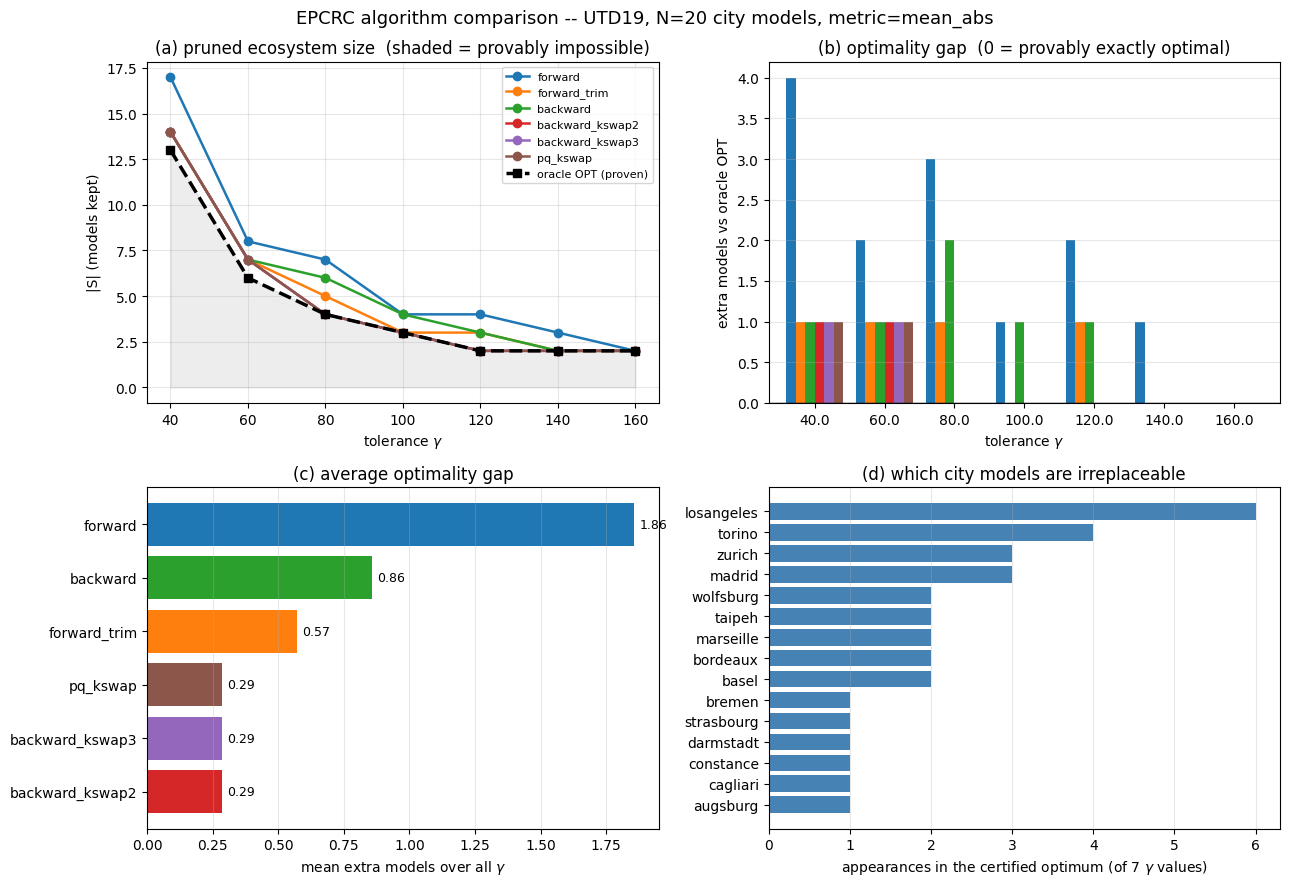

In [4]:
# MASTER FIGURE: every algorithm, four views.
#   (a) size vs gamma      -- the headline curve, with the proven bound shaded
#   (b) gap per gamma      -- where each method loses models
#   (c) mean gap ranking   -- one number per algorithm
#   (d) survivor frequency -- which cities the certified optimum keeps
COLORS = dict(zip(ALGOS, plt.cm.tab10.colors))
oracle_s = oracle.dropna().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
for algo in ALGOS:
    s = df[df.algorithm == algo].sort_values("gamma")
    ax.plot(s["gamma"], s["size"], marker="o", lw=1.8, color=COLORS[algo], label=algo)
ax.plot(oracle_s.index, oracle_s.values, "k--", marker="s", lw=2.5,
        label="oracle OPT (proven)")
ax.fill_between(oracle_s.index, 0, oracle_s.values, color="k", alpha=0.07)
ax.set(xlabel="tolerance $\\gamma$", ylabel="|S| (models kept)",
       title="(a) pruned ecosystem size  (shaded = provably impossible)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
gap.T.plot(kind="bar", ax=ax, width=0.82, color=[COLORS[a] for a in gap.index], legend=False)
ax.axhline(0, color="k", lw=1)
ax.set(xlabel="tolerance $\\gamma$", ylabel="extra models vs oracle OPT",
       title="(b) optimality gap  (0 = provably exactly optimal)")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)

ax = axes[1, 0]
mean_gap = gap.mean(axis=1).sort_values()
ax.barh(mean_gap.index, mean_gap.values, color=[COLORS[a] for a in mean_gap.index])
for y, v in enumerate(mean_gap.values):
    ax.text(v + 0.02, y, f"{v:.2f}", va="center", fontsize=9)
ax.set(xlabel="mean extra models over all $\\gamma$", title="(c) average optimality gap")
ax.grid(axis="x", alpha=0.3)

ax = axes[1, 1]
keep_counts = pd.Series(
    [n for r in payload["records"] for n in r["oracle"].get("optimum_names", [])]
).value_counts().sort_values()
n_certified = sum(r["oracle"].get("optimum") is not None for r in payload["records"])
ax.barh(keep_counts.index, keep_counts.values, color="steelblue")
ax.set(xlabel=f"appearances in the certified optimum (of {n_certified} $\\gamma$ values)",
       title="(d) which city models are irreplaceable")
ax.grid(axis="x", alpha=0.3)

fig.suptitle(f"EPCRC algorithm comparison -- UTD19, N={cfg['n_models']} city models, "
             f"metric={cfg['metric']}", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "results", "comparison_all_algorithms.png"), dpi=150)

## Optimality gap

`size - oracle optimum`, in models. This is an *upper bound* on the true protocol gap,
because the oracle optimum can itself be strictly below the protocol optimum. A pruner
showing gap 0 is therefore provably exactly optimal.

In [5]:
display(gap)
print("mean gap over gammas (lower is better):")
print(gap.mean(axis=1).round(2).sort_values().to_string())

gamma,40.0,60.0,80.0,100.0,120.0,140.0,160.0
algorithm,,,,,,,
forward,4,2,3,1,2,1,0
forward_trim,1,1,1,0,1,0,0
backward,1,1,2,1,1,0,0
backward_kswap2,1,1,0,0,0,0,0
backward_kswap3,1,1,0,0,0,0,0
pq_kswap,1,1,0,0,0,0,0


mean gap over gammas (lower is better):
algorithm
backward_kswap2    0.29
backward_kswap3    0.29
pq_kswap           0.29
forward_trim       0.57
backward           0.86
forward            1.86


## Minimality check

`n_droppable` counts models that could still be removed while staying feasible. A pruner
with a non-zero count is not even locally minimal, so its size is not comparable to a
pruner that is.

This is exactly where the two forward variants separate: `forward` leaves droppable models
behind, every other method here ends minimal (backward by construction, `forward_trim`
because it runs backward's trim afterwards). So the fair like-for-like comparison against
`backward` is `forward_trim`, and the honest reading of plain `forward` is that part of its
gap is slack it simply never tried to remove.

In [6]:
drop = df.pivot(index="algorithm", columns="gamma", values="n_droppable").reindex(ALGOS)
print("droppable models remaining (non-zero => not locally minimal):")
display(drop)

assert (df["feasible"]).all(), "a pruner returned an infeasible set"
bad = df.dropna(subset=["gap_to_oracle"]).query("gap_to_oracle < 0")
assert bad.empty, f"pruner beat the proven oracle bound (bug):\n{bad}"

# Only untrimmed forward is allowed to be non-minimal; anything else would be a bug.
non_minimal = set(drop.index[(drop > 0).any(axis=1)])
assert non_minimal <= {"forward"}, f"unexpectedly non-minimal pruners: {non_minimal - {'forward'}}"
print("OK: every set feasible, none beats the proven bound, "
      "and only untrimmed `forward` is non-minimal.")

droppable models remaining (non-zero => not locally minimal):


gamma,40.0,60.0,80.0,100.0,120.0,140.0,160.0
algorithm,,,,,,,
forward,3,1,3,1,2,1,0
forward_trim,0,0,0,0,0,0,0
backward,0,0,0,0,0,0,0
backward_kswap2,0,0,0,0,0,0,0
backward_kswap3,0,0,0,0,0,0,0
pq_kswap,0,0,0,0,0,0,0


OK: every set feasible, none beats the proven bound, and only untrimmed `forward` is non-minimal.


## Which cities survive

The certified optimal sets, with how each optimum was proven.

In [7]:
for rec in payload["records"]:
    o = rec["oracle"]
    if o.get("optimum") is None:
        print(f"gamma={rec['gamma']:>5g}  UNPROVEN (lower bound {o.get('lower_bound')})")
        continue
    print(f"gamma={rec['gamma']:>5g}  |S*|={o['optimum']:<3} [{o['proof']:>11}]  "
          f"{', '.join(o['optimum_names'])}")

gamma=   40  |S*|=13  [       milp]  augsburg, basel, bordeaux, cagliari, constance, darmstadt, losangeles, madrid, marseille, strasbourg, taipeh, torino, wolfsburg
gamma=   60  |S*|=6   [       milp]  bordeaux, losangeles, madrid, marseille, torino, zurich
gamma=   80  |S*|=4   [enumeration]  basel, bremen, losangeles, madrid
gamma=  100  |S*|=3   [enumeration]  losangeles, torino, zurich
gamma=  120  |S*|=2   [enumeration]  losangeles, wolfsburg
gamma=  140  |S*|=2   [enumeration]  losangeles, zurich
gamma=  160  |S*|=2   [enumeration]  taipeh, torino


## Cost

Wall-clock per pruner, plus how the oracle optimum was obtained at each gamma.

In [8]:
display(df.pivot(index="algorithm", columns="gamma", values="time_s").reindex(ALGOS))

pd.DataFrame([{
    "gamma": r["gamma"],
    "proof": r["oracle"].get("proof"),
    "certified_upto_k": r["oracle"].get("certified_upto_k"),
    "subsets_tested": r["oracle"].get("n_subsets_tested"),
    "certify_s": r["oracle"].get("certify_time_s"),
    "milp_s": r["oracle"].get("milp_time_s"),
} for r in payload["records"]]).set_index("gamma")

gamma,40.0,60.0,80.0,100.0,120.0,140.0,160.0
algorithm,,,,,,,
forward,0.28,0.17,0.16,0.08,0.08,0.06,0.03
forward_trim,0.33,0.19,0.17,0.08,0.08,0.06,0.03
backward,0.10,0.21,0.22,0.24,0.23,0.23,0.23
backward_kswap2,0.85,0.61,0.36,0.34,0.25,0.25,0.24
backward_kswap3,8.42,4.62,0.96,0.50,0.25,0.24,0.24
pq_kswap,0.85,0.53,0.41,0.12,0.05,0.04,0.03


,proof,certified_upto_k,subsets_tested,certify_s,milp_s
gamma,,,,,
40.0,milp,4,6195,30.01,327.17
60.0,milp,4,6195,30.77,210.50
80.0,enumeration,3,2997,18.73,NaN
100.0,enumeration,2,210,1.15,NaN
120.0,enumeration,1,20,0.65,NaN
140.0,enumeration,1,20,0.62,NaN
160.0,enumeration,1,20,0.63,NaN
